# Task 5: Government, Budget, and Statistical Evidence

This notebook collects UK government, budget, and statistical evidence related to housing promises in the UK Labour 2024 manifesto.

The goal is to create an outcome evidence dataset that can later be linked to specific promise IDs from the promise extraction task.

In [1]:
import sys
print(sys.executable)

c:\Users\darko\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [2]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
csv_path = project_root / "data" / "processed" / "outcome_evidence.csv"

outcome_evidence = pd.read_csv(csv_path)
outcome_evidence.head()

,indicator_id,linked_promise_ids,policy_area,source_type,source_name,source_url,indicator_name,geography,time_period,value_or_description,relevance_to_promise,notes
0,O01,H01;H07,Housing,Statistics,GOV.UK Housing supply net additional dwellings,https://www.gov.uk/government/statistics/housi...,Net additional dwellings,England,2024-2025,Annual housing supply in England amounted to 2...,Relevant to promises about increasing housing ...,Outcome indicator for housing delivery.
1,O02,H01;H07,Housing,Statistics,ONS UK housebuilding starts and completions,https://www.ons.gov.uk/peoplepopulationandcomm...,Housebuilding starts and completions,UK,Quarterly dataset,ONS dataset bringing together quarterly UK tot...,Relevant to promises about increasing housebui...,Useful measurable indicator because it tracks ...
2,O03,H01;H02;H03;H05,Housing,Government policy,GOV.UK Planning overhaul to reach 1.5 million ...,https://www.gov.uk/government/news/planning-ov...,Planning reform and housing target,England,2024,Government announcement on planning reform con...,"Relevant to promises about planning reform, ho...",Policy action evidence rather than final outco...
3,O04,H02;H03;H05,Housing,Government policy,National Planning Policy Framework,https://www.gov.uk/government/publications/nat...,Planning policy framework,England,2024-2025,The National Planning Policy Framework sets ou...,Relevant to promises about updating planning r...,Useful for checking whether planning-related p...
4,O05,H07;H08,Housing,Statistics,GOV.UK Affordable housing supply in England 20...,https://www.gov.uk/government/statistics/affor...,Affordable housing supply,England,2024-2025,"Official statistics on new affordable homes, i...",Relevant to promises about social and affordab...,Outcome indicator for affordable housing deliv...


In [3]:
outcome_evidence.shape

(12, 12)

In [4]:
outcome_evidence["source_type"].value_counts()

source_type
Government policy     6
Statistics            4
Government funding    2
Name: count, dtype: int64

In [5]:
linked_promises = outcome_evidence["linked_promise_ids"].str.split(";").explode()
linked_promises.value_counts()

linked_promise_ids
H07    6
H01    4
H08    3
H02    2
H03    2
H05    2
H11    2
H12    2
H13    1
H14    1
H09    1
H10    1
Name: count, dtype: int64

In [6]:
outcome_evidence[["indicator_id", "linked_promise_ids", "source_type", "source_name", "indicator_name", "relevance_to_promise"]]

,indicator_id,linked_promise_ids,source_type,source_name,indicator_name,relevance_to_promise
0,O01,H01;H07,Statistics,GOV.UK Housing supply net additional dwellings,Net additional dwellings,Relevant to promises about increasing housing ...
1,O02,H01;H07,Statistics,ONS UK housebuilding starts and completions,Housebuilding starts and completions,Relevant to promises about increasing housebui...
2,O03,H01;H02;H03;H05,Government policy,GOV.UK Planning overhaul to reach 1.5 million ...,Planning reform and housing target,"Relevant to promises about planning reform, ho..."
3,O04,H02;H03;H05,Government policy,National Planning Policy Framework,Planning policy framework,Relevant to promises about updating planning r...
4,O05,H07;H08,Statistics,GOV.UK Affordable housing supply in England 20...,Affordable housing supply,Relevant to promises about social and affordab...
5,O06,H07;H08,Government funding,Affordable Homes Programme annual report 2024 ...,Affordable homes funding and delivery,Relevant to promises about increasing social a...
6,O07,H07;H08,Government funding,Delivering a decade of renewal for social and ...,Social and affordable housing investment,Relevant to promises about the biggest increas...
7,O08,H11;H12,Government policy,Renters' Rights Bill,Renters' rights and private renting reform,Relevant to promises about abolishing Section ...
8,O09,H11;H12,Government policy,GOV.UK Renters' Rights Bill guide,Private rented sector reform,Relevant to promises about renters' protection...
9,O10,H13;H14,Government policy,Leasehold and Freehold Reform Act 2024,Leasehold and ground rent reform,Relevant to promises about leasehold reform an...


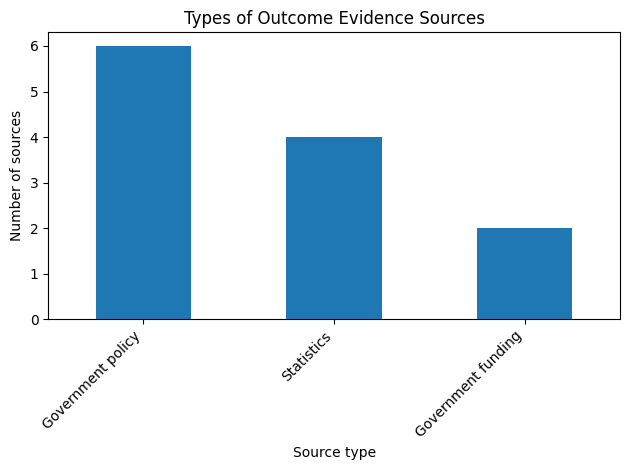

In [7]:
import matplotlib.pyplot as plt

source_counts = outcome_evidence["source_type"].value_counts()

source_counts.plot(kind="bar")
plt.title("Types of Outcome Evidence Sources")
plt.xlabel("Source type")
plt.ylabel("Number of sources")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()